# SENN on FashionMNIST — Exploration Report

This notebook explores the results of two SENN runs trained on **FashionMNIST** (λ = 1e-4):
- **c10**: 10 concepts (`fashion_mnist_lambda1e-4_c10_seed29`)
- **c5**: 5 concepts (`fashion_mnist_lambda1e-4_c5_seed29`)

For each run we analyse:
1. Training and validation curves
2. Test accuracy
3. SENN explanations on random samples
4. SENN explanations for one sample per class
5. Concept prototypes (highest activation + highest contrast)

A final section compares the two runs side-by-side and provides a template for a future λ-sweep comparison.

**FashionMNIST class labels:**

| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

In [1]:
# ─── Cell 1: Imports ─────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
from pathlib import Path

# SENN modules
from senn.trainer import SENN_Trainer
from senn.utils.plot_utils import show_explainations
from senn.utils.concept_representations import highest_activations, highest_contrast

plt.style.use('seaborn-v0_8-talk')
%matplotlib inline

FASHION_MNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Imports OK')

Imports OK


In [2]:
# ─── Cell 2: Helper functions ─────────────────────────────────────────────────

def load_senn(config_path, device='cpu'):
    """
    Load a trained SENN from config + best_model.pt checkpoint.
    
    Raises FileNotFoundError explicitly if the checkpoint is missing,
    instead of silently starting from scratch (trainer's try/except OSError
    would otherwise swallow the error and leave the model with random weights).
    """
    with open(config_path, 'r') as f:
        config = json.load(f)

    config['device'] = device
    config['train'] = False
    # Do NOT set load_checkpoint here — we load manually below
    # to get a visible error if the file is missing.
    config = SimpleNamespace(**config)

    # Build the expected checkpoint path (mirrors trainer.py logic)
    checkpoint_path = (
        Path('results') / config.exp_name / 'checkpoints' / 'best_model.pt'
    )
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"\n[ERROR] Checkpoint not found at: {checkpoint_path}\n"
            f"  → Copy best_model.pt from the training machine to:\n"
            f"    {checkpoint_path.resolve()}"
        )

    # Instantiate trainer (without auto-loading checkpoint)
    trainer = SENN_Trainer(config)

    # Load checkpoint manually with weights_only=False for PyTorch >= 2.0
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    trainer.model.load_state_dict(checkpoint['model_state'])
    trainer.best_accuracy = checkpoint['best_accuracy']
    print(f"✓ Checkpoint loaded from: {checkpoint_path}")
    print(f"  Best validation accuracy recorded during training: "
          f"{checkpoint['best_accuracy']*100:.2f} %")

    trainer.model.eval()
    return trainer


def plot_training_curves(exp_name, results_dir='results'):
    """
    Plot accuracy and loss curves from the saved CSVs.

    Layout (2 rows × 3 cols):
      Row 0: Accuracy (train+valid) | Classification Loss (train+valid) | Concept Loss (train+valid)
      Row 1: Robustness Loss (train only) | Total Loss — TRAIN only | Total Loss — VALID only

    Notes on why train > valid in the Total Loss panel:
      • Dropout (p=0.5) is ACTIVE during training → harder task → higher loss.
      • Robustness loss uses the Jacobian, which requires grad → it is hardcoded
        to 0.0 during validation (no_grad context). So the valid total loss is
        effectively classification + concept only, making it systematically lower.
    """
    train_csv = Path(results_dir) / exp_name / 'accuracies_losses_train.csv'
    valid_csv = Path(results_dir) / exp_name / 'accuracies_losses_valid.csv'

    df_t = pd.read_csv(train_csv)
    df_v = pd.read_csv(valid_csv)

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle(f'Training Curves — {exp_name}', fontsize=13, fontweight='bold')

    # ── Row 0 ──────────────────────────────────────────────────────────────────

    # Accuracy
    axes[0, 0].plot(df_t['Step'], df_t['Accuracy'], label='Train', alpha=0.7)
    axes[0, 0].plot(df_v['Step'], df_v['Accuracy'], label='Validation',
                    marker='o', linewidth=2)
    axes[0, 0].set_title('Accuracy')
    axes[0, 0].set_xlabel('Step'); axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend(); axes[0, 0].grid(True)

    # Classification Loss
    axes[0, 1].plot(df_t['Step'], df_t['Classification_Loss'], label='Train', alpha=0.7)
    axes[0, 1].plot(df_v['Step'], df_v['Classification_Loss'], label='Validation',
                    marker='o', linewidth=2)
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].set_xlabel('Step'); axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend(); axes[0, 1].grid(True)

    # Concept Loss
    axes[0, 2].plot(df_t['Step'], df_t['Concept_Loss'], label='Train', alpha=0.7)
    axes[0, 2].plot(df_v['Step'], df_v['Concept_Loss'], label='Validation',
                    marker='o', linewidth=2)
    axes[0, 2].set_title('Concept Loss (MSE + L1 sparsity)')
    axes[0, 2].set_xlabel('Step'); axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend(); axes[0, 2].grid(True)

    # ── Row 1 ──────────────────────────────────────────────────────────────────

    # Robustness Loss (train only — always 0 in validation)
    axes[1, 0].plot(df_t['Step'], df_t['Robustness_Loss'],
                    label='Train', alpha=0.8, color='tab:green')
    axes[1, 0].set_title('Robustness Loss (train only)')
    axes[1, 0].set_xlabel('Step'); axes[1, 0].set_ylabel('Loss')
    axes[1, 0].text(0.05, 0.92,
                    'Always 0 in validation:\nJacobian requires grad,\n'
                    'but validation uses no_grad.',
                    transform=axes[1, 0].transAxes, fontsize=8,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 0].legend(); axes[1, 0].grid(True)

    # Total Loss — Train only
    axes[1, 1].plot(df_t['Step'], df_t['Loss'],
                    label='Train total loss', alpha=0.8, color='tab:blue')
    axes[1, 1].set_title('Total Loss — Train\n(classification + concept + robustness)')
    axes[1, 1].set_xlabel('Step'); axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend(); axes[1, 1].grid(True)

    # Total Loss — Validation only
    axes[1, 2].plot(df_v['Step'], df_v['Loss'],
                    label='Validation total loss', marker='o',
                    linewidth=2, color='tab:orange')
    axes[1, 2].set_title('Total Loss — Validation\n(classification + concept only,  robustness = 0)')
    axes[1, 2].set_xlabel('Step'); axes[1, 2].set_ylabel('Loss')
    axes[1, 2].text(0.05, 0.92,
                    '⚠ Not directly comparable\nto Train total loss:\n'
                    'robustness term is missing\n(hardcoded to 0 in trainer.py)',
                    transform=axes[1, 2].transAxes, fontsize=8,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 2].legend(); axes[1, 2].grid(True)

    plt.tight_layout()
    plt.show()


def get_one_per_class(test_loader, num_classes=10, device='cpu'):
    """Return a stacked tensor with one image per class."""
    examples = {}
    for x, y in test_loader:
        for i in range(len(y)):
            label = y[i].item()
            if label not in examples:
                examples[label] = x[i]
            if len(examples) == num_classes:
                break
        if len(examples) == num_classes:
            break
    return torch.stack([examples[i] for i in range(num_classes)]).to(device)


def show_per_class_explanations(model, test_loader, class_names,
                                device='cpu', group_size=5):
    """Show SENN explanations (image + θ + h) for one sample per class."""
    images = get_one_per_class(test_loader, num_classes=len(class_names), device=device)
    model.eval()
    with torch.no_grad():
        y_pred, (concepts, relevances), _ = model(images)
    y_pred_idx = y_pred.argmax(1)

    num_concepts = concepts.shape[1]
    concept_lim = max(abs(concepts.min().item()), abs(concepts.max().item())) + 0.1
    y_labels = [f'C{j+1}' for j in range(num_concepts - 1, -1, -1)]

    for group_start in range(0, len(class_names), group_size):
        group_end = min(group_start + group_size, len(class_names))
        n = group_end - group_start

        fig, axes = plt.subplots(3, n, figsize=(3.2 * n, 3.2 * 3))
        if n == 1:
            axes = axes[:, np.newaxis]

        for col, idx in enumerate(range(group_start, group_end)):
            true_label = class_names[idx]
            pred_label = class_names[y_pred_idx[idx].item()]
            title_color = 'green' if true_label == pred_label else 'red'

            # Row 0 — input image
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(
                f'True: {true_label}\nPred: {pred_label}',
                fontsize=9, color=title_color
            )
            axes[0, col].axis('off')

            # Row 1 — relevance scores theta
            rs = relevances[idx, :, y_pred_idx[idx].item()].cpu()
            colors_r = ['b' if v > 0 else 'r' for v in rs.tolist()][::-1]
            axes[1, col].barh(np.arange(num_concepts), np.flip(rs.numpy()),
                              color=colors_r, align='center')
            axes[1, col].set_yticks(np.arange(num_concepts))
            axes[1, col].set_yticklabels(y_labels, fontsize=8)
            axes[1, col].set_xlim(-1.1, 1.1)
            axes[1, col].axvline(0, color='black', linewidth=0.6, linestyle='--')
            if col == 0:
                axes[1, col].set_ylabel('Relevances θ', fontsize=10)

            # Row 2 — concept activations h
            cs = concepts[idx].flatten().cpu()
            colors_c = ['b' if v > 0 else 'r' for v in cs.tolist()][::-1]
            axes[2, col].barh(np.arange(num_concepts), np.flip(cs.numpy()),
                              color=colors_c, align='center')
            axes[2, col].set_yticks(np.arange(num_concepts))
            axes[2, col].set_yticklabels(y_labels, fontsize=8)
            axes[2, col].set_xlim(-concept_lim, concept_lim)
            axes[2, col].axvline(0, color='black', linewidth=0.6, linestyle='--')
            if col == 0:
                axes[2, col].set_ylabel('Concepts h', fontsize=10)

        plt.suptitle(
            f'Classes {group_start}–{group_end - 1}: '
            + ', '.join(class_names[group_start:group_end]),
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()


print('Helper functions loaded.')

Helper functions loaded.


---
## 1. Run c10 — 10 Concepts, λ = 1e-4
`fashion_mnist_lambda1e-4_c10_seed29`

In [3]:
# ─── Load c10 ────────────────────────────────────────────────────────────────
CONFIG_C10 = 'configs/fashion_mnist_lambda1e-4_c10_seed29.json'
EXP_C10    = 'fashion_mnist_lambda1e-4_c10_seed29'

trainer_c10     = load_senn(CONFIG_C10, device='cpu')
model_c10       = trainer_c10.model
test_loader_c10 = trainer_c10.test_loader

Using device cpu
Loading data ...
SENN(
  (conceptizer): ConvConceptizer(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(10, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (2): ScalarMapping(
        (layers): ModuleList(
          (0-9): 10 x Linear(in_features=16, out_features=1, bias=True)
        )
      )
    )
    (decoder): ModuleList(
      (0): Sequential(
        (0): ConvTranspose2d(10, 16, kernel_size=(5, 5), stride=(2, 2))
      )
      (1): ReLU(inplace=True)
      (2): Sequential(
        (0): ConvTranspose2d(16, 8, kernel_size=(5, 5), stride=(1, 1))
      )
      (3): ReLU(inplace=True)
      (4): Sequential(
     

### 1.1 Training and Validation Curves

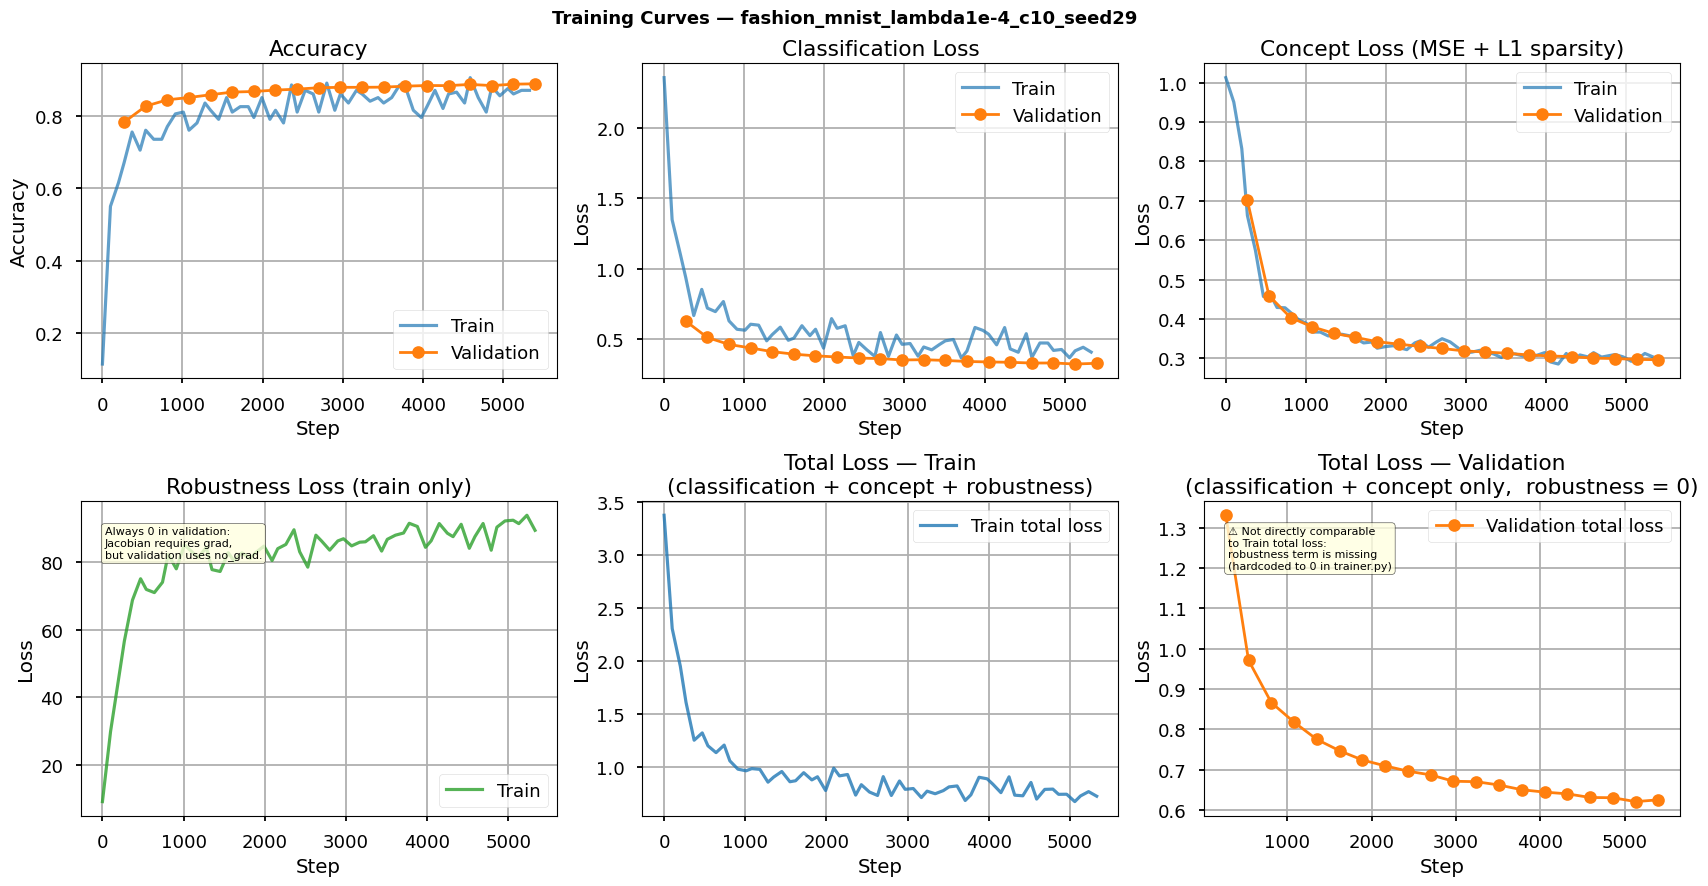

In [4]:
plot_training_curves(EXP_C10)

### 1.2 Test Accuracy

In [5]:
acc_c10 = trainer_c10.test()
print(f'\n>>> Test Accuracy (c10): {acc_c10:.4f}  ({acc_c10 * 100:.2f} %)')


-------- Test --------
Total Loss:0.650 	Classification Loss:0.353 	Robustness Loss:0.000 	Concept Loss:0.297 	Accuracy:0.877 	
----------------------------

>>> Test Accuracy (c10): 0.8768  (87.68 %)


### 1.3 SENN Explanations — Random Samples

Each panel shows: **input image** · **relevance scores θ** (how much each concept contributes to the prediction) · **concept activations h** (the values of the latent concepts).

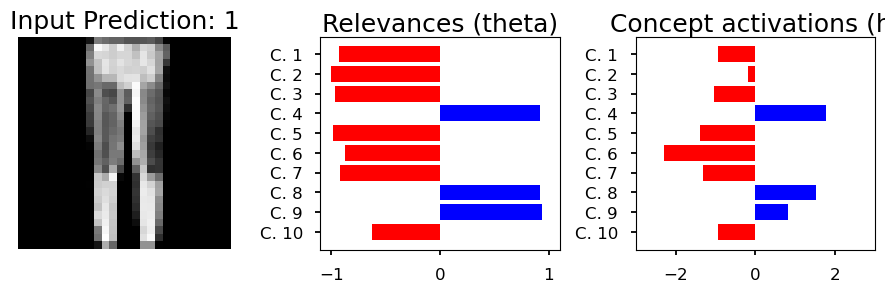

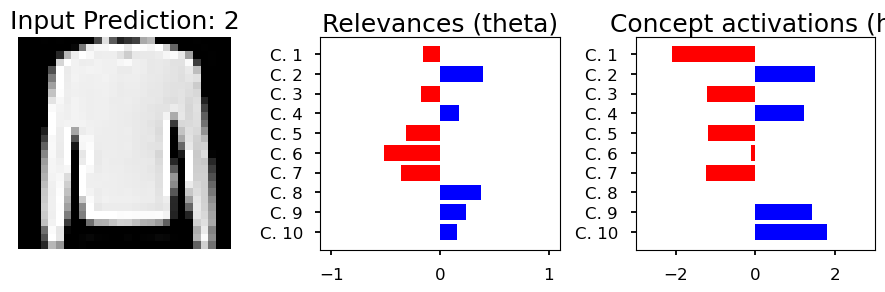

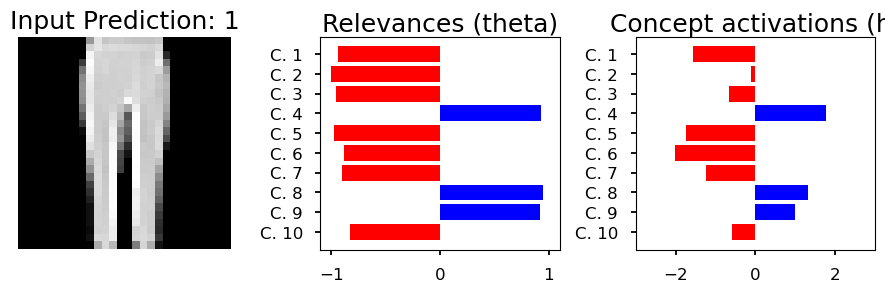

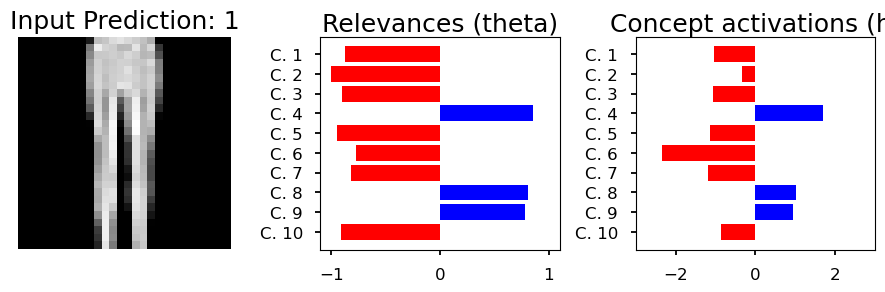

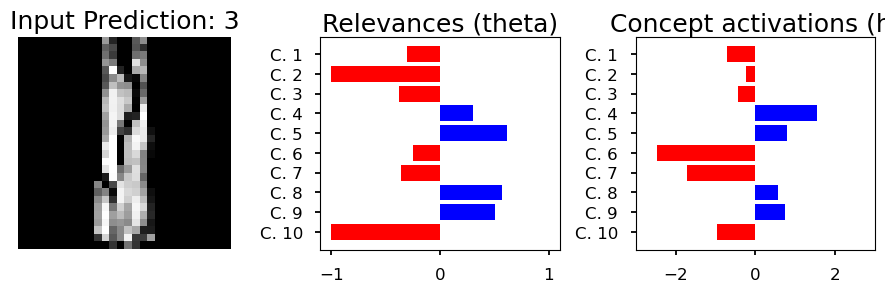

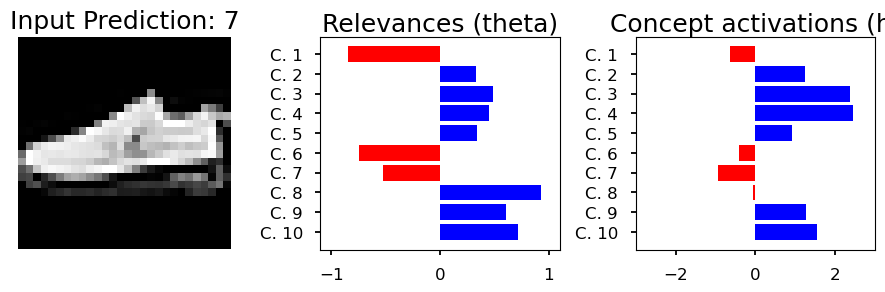

In [6]:
show_explainations(
    model_c10, test_loader_c10,
    dataset='fashion_mnist',
    num_explanations=6,
    batch_size=200
)

### 1.4 SENN Explanations — One Sample per Class

The title is **green** when the model predicts the correct class, **red** otherwise.

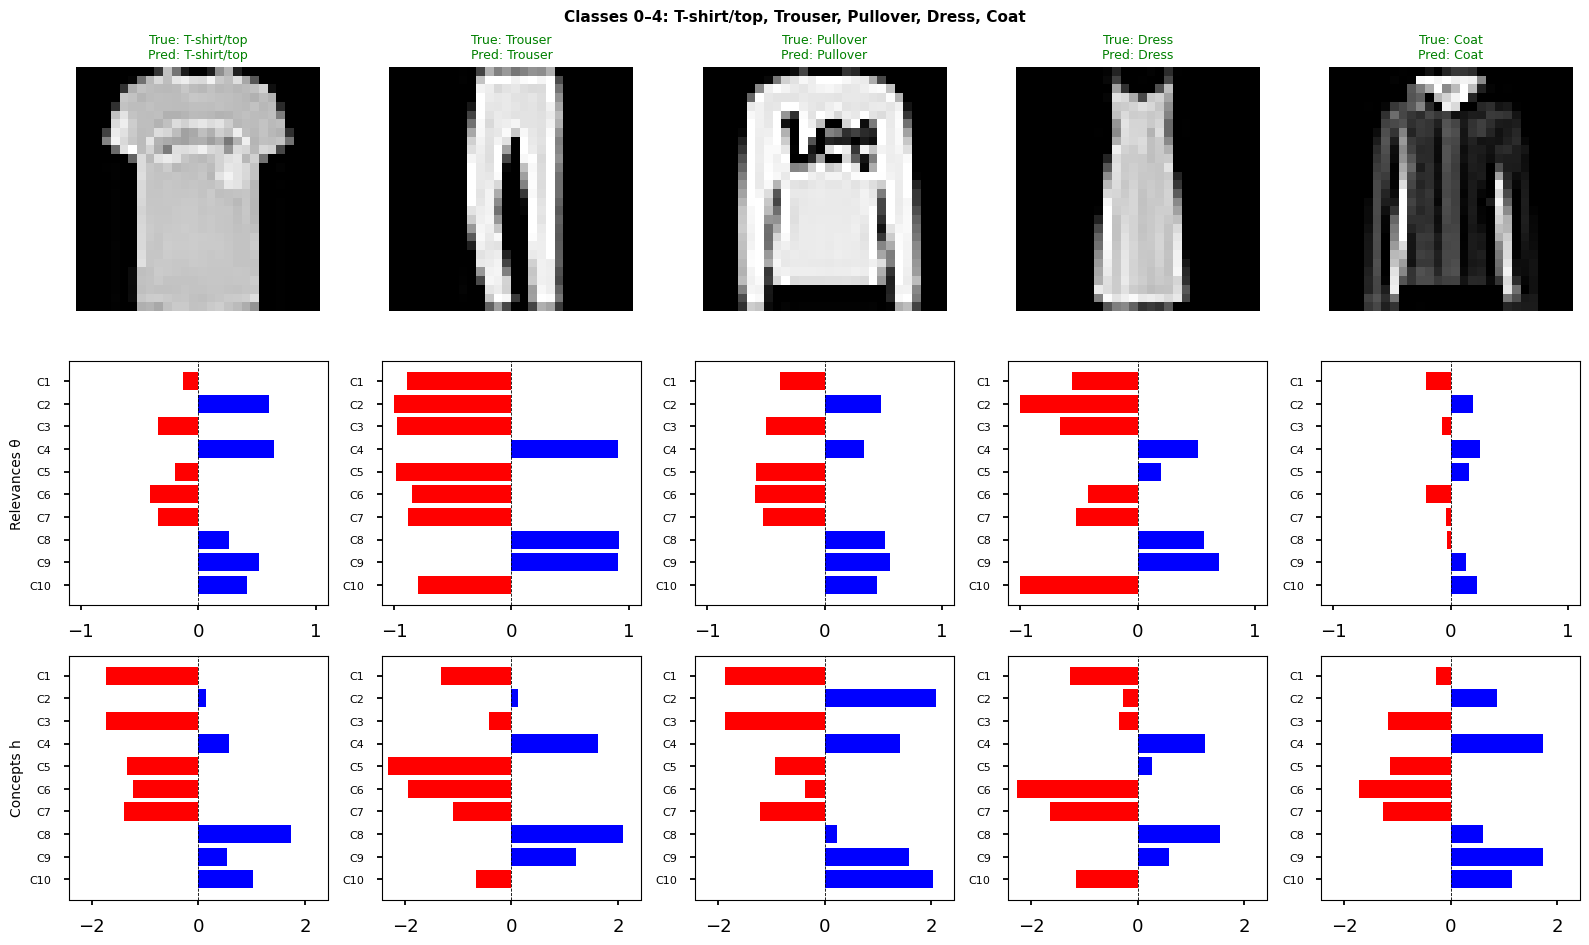

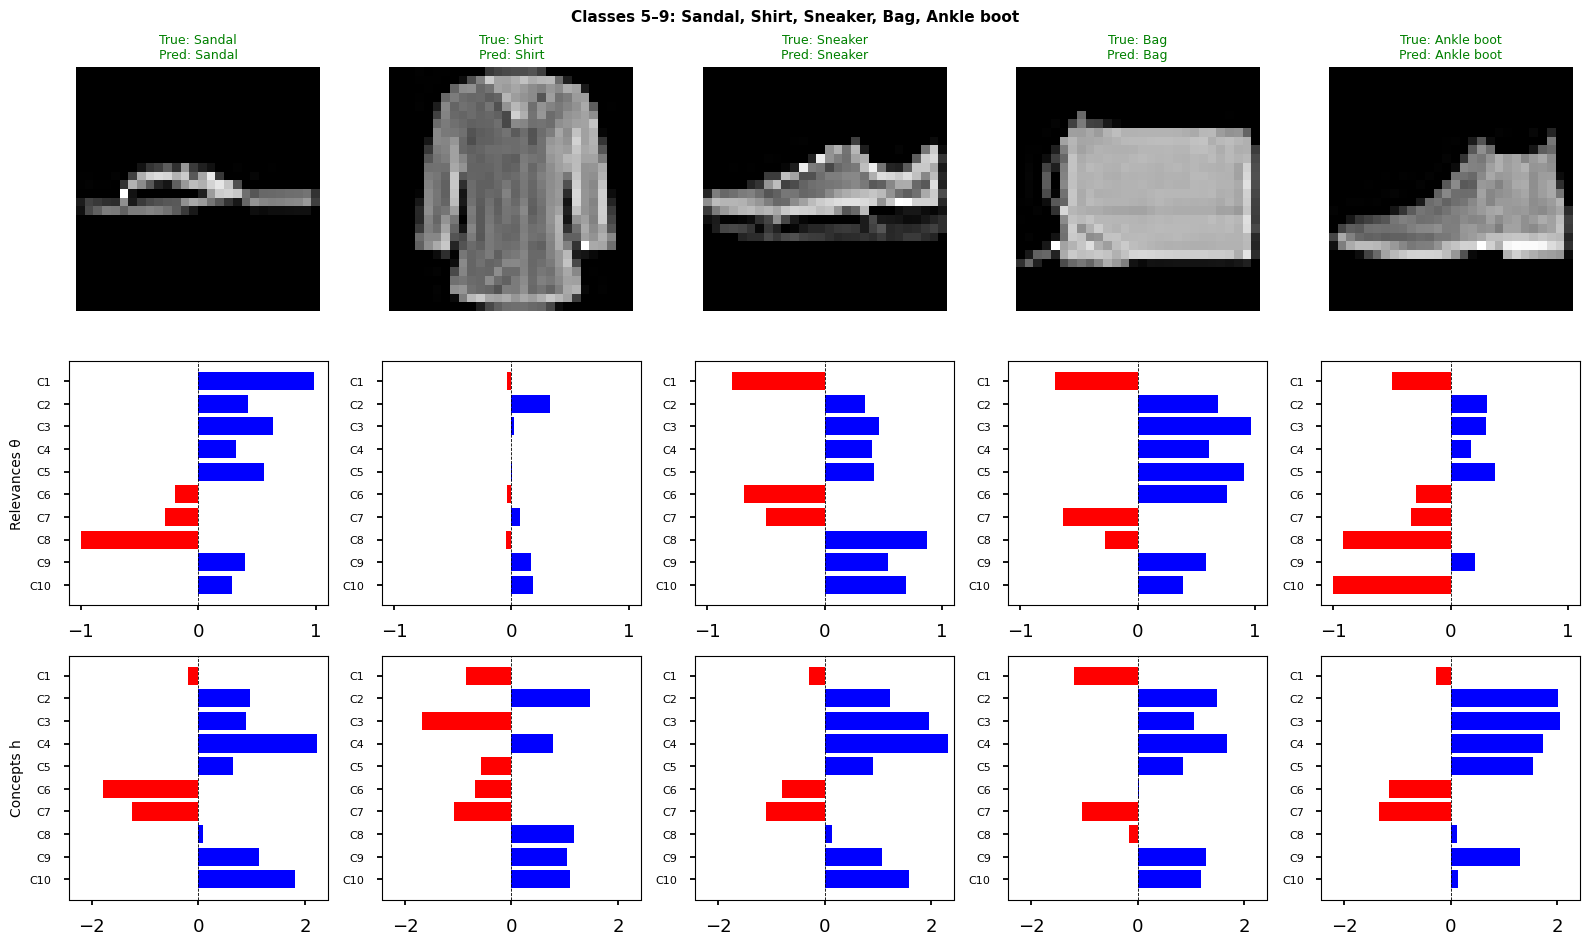

In [7]:
show_per_class_explanations(
    model_c10, test_loader_c10,
    class_names=FASHION_MNIST_CLASSES,
    device='cpu',
    group_size=5
)

### 1.5 Concept Prototypes — Highest Activation

For each concept, the **9 test-set images that produce the highest activation** for that concept.

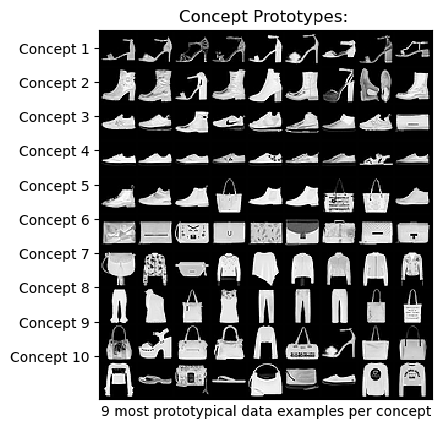

<Figure size 640x480 with 0 Axes>

In [8]:
highest_activations(
    model_c10, test_loader_c10,
    num_concepts=10,
    num_prototypes=9
)

### 1.6 Concept Prototypes — Highest Contrast

For each concept, the **9 images that activate it most exclusively** (high activation for that concept, low for all others).

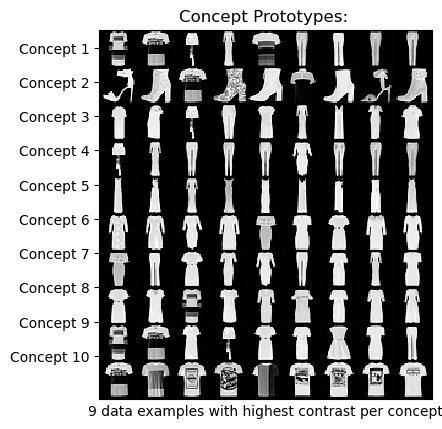

<Figure size 640x480 with 0 Axes>

In [9]:
highest_contrast(
    model_c10, test_loader_c10,
    num_concepts=10,
    num_prototypes=9
)

---
## 2. Run c5 — 5 Concepts, λ = 1e-4
`fashion_mnist_lambda1e-4_c5_seed29`

In [10]:
# ─── Load c5 ─────────────────────────────────────────────────────────────────
CONFIG_C5 = 'configs/fashion_mnist_lambda1e-4_c5_seed29.json'
EXP_C5    = 'fashion_mnist_lambda1e-4_c5_seed29'

trainer_c5     = load_senn(CONFIG_C5, device='cpu')
model_c5       = trainer_c5.model
test_loader_c5 = trainer_c5.test_loader

Using device cpu
Loading data ...
SENN(
  (conceptizer): ConvConceptizer(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (2): ScalarMapping(
        (layers): ModuleList(
          (0-4): 5 x Linear(in_features=16, out_features=1, bias=True)
        )
      )
    )
    (decoder): ModuleList(
      (0): Sequential(
        (0): ConvTranspose2d(5, 16, kernel_size=(5, 5), stride=(2, 2))
      )
      (1): ReLU(inplace=True)
      (2): Sequential(
        (0): ConvTranspose2d(16, 8, kernel_size=(5, 5), stride=(1, 1))
      )
      (3): ReLU(inplace=True)
      (4): Sequential(
        

### 2.1 Training and Validation Curves

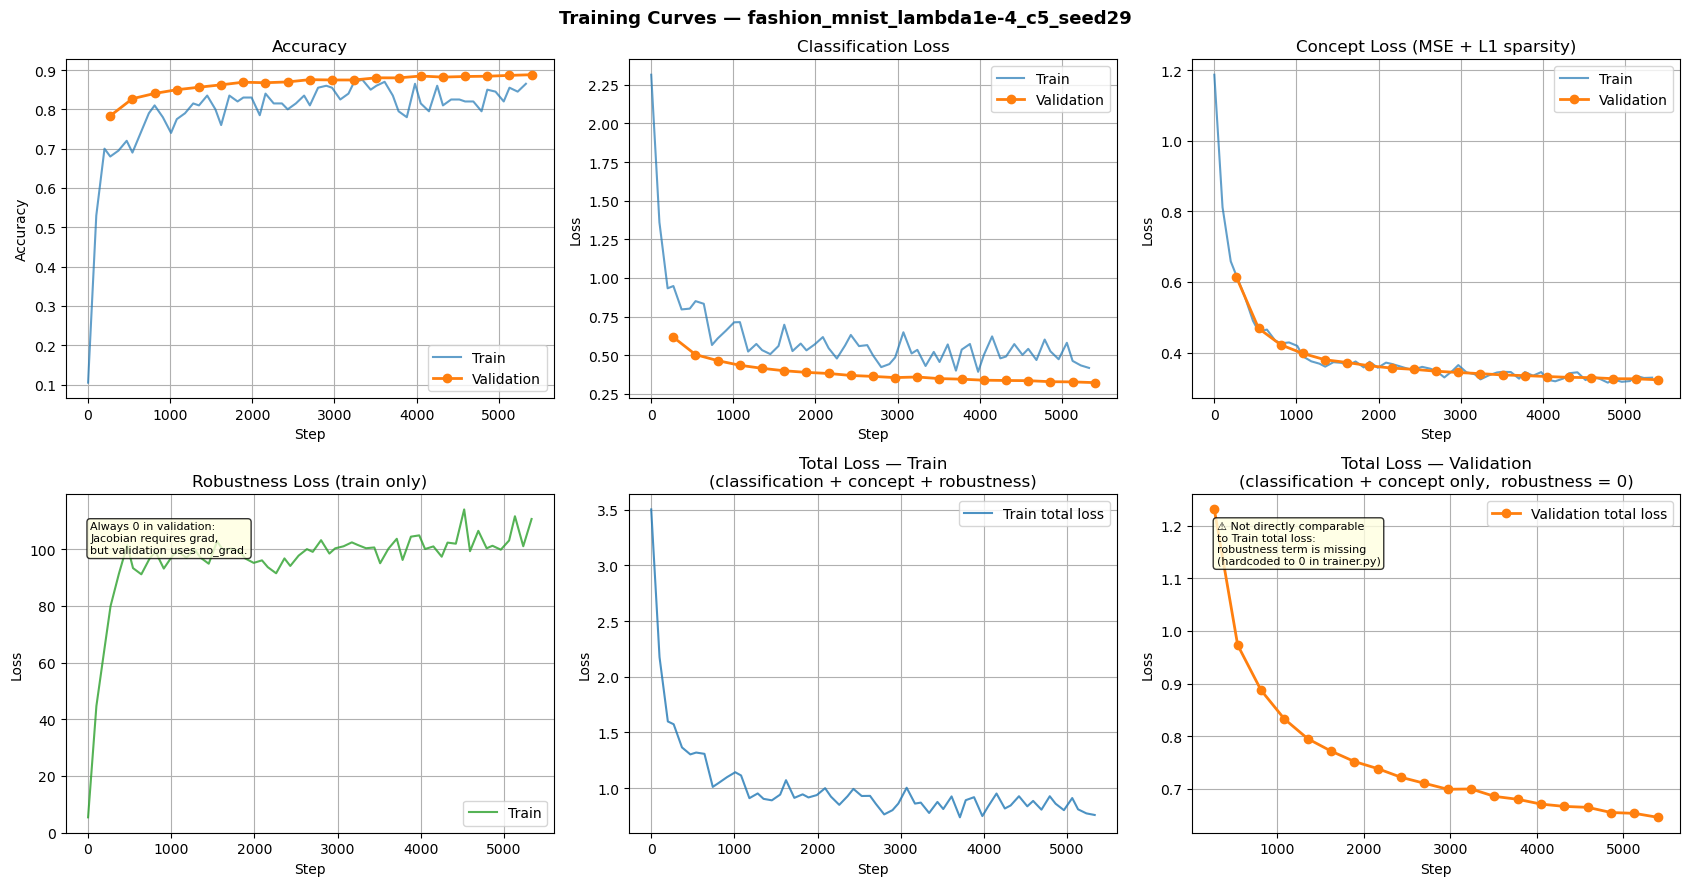

In [11]:
plot_training_curves(EXP_C5)

### 2.2 Test Accuracy

In [12]:
acc_c5 = trainer_c5.test()
print(f'\n>>> Test Accuracy (c5): {acc_c5:.4f}  ({acc_c5 * 100:.2f} %)')


-------- Test --------
Total Loss:0.675 	Classification Loss:0.354 	Robustness Loss:0.000 	Concept Loss:0.322 	Accuracy:0.877 	
----------------------------

>>> Test Accuracy (c5): 0.8768  (87.68 %)


### 2.3 SENN Explanations — Random Samples

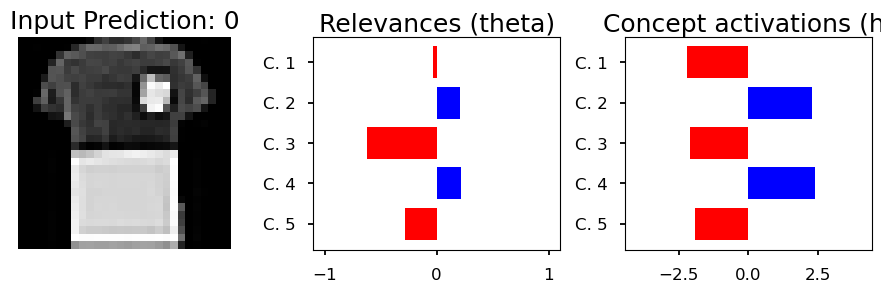

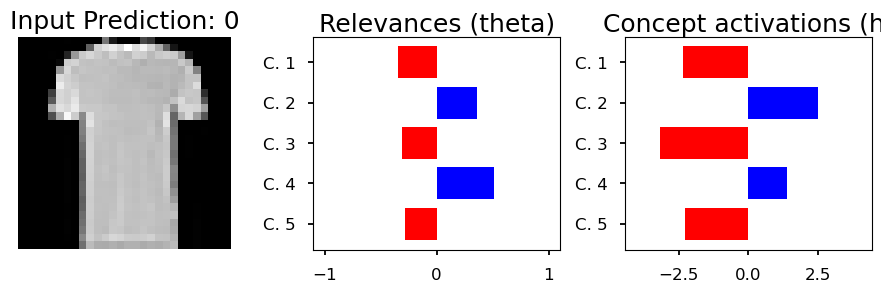

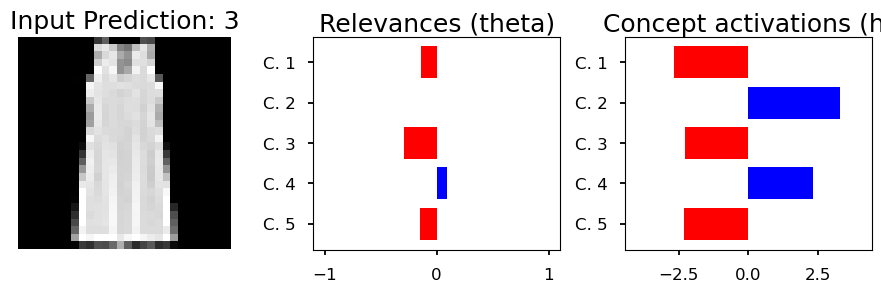

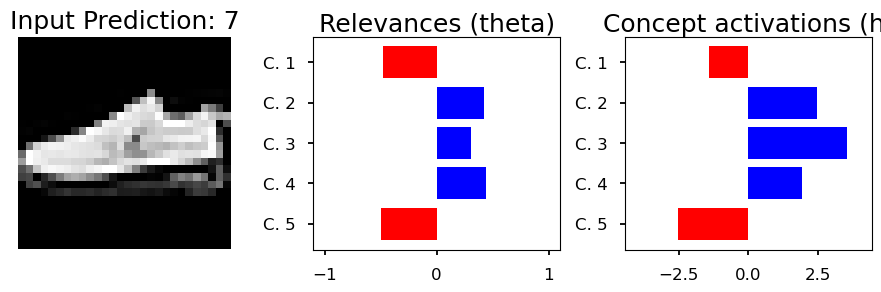

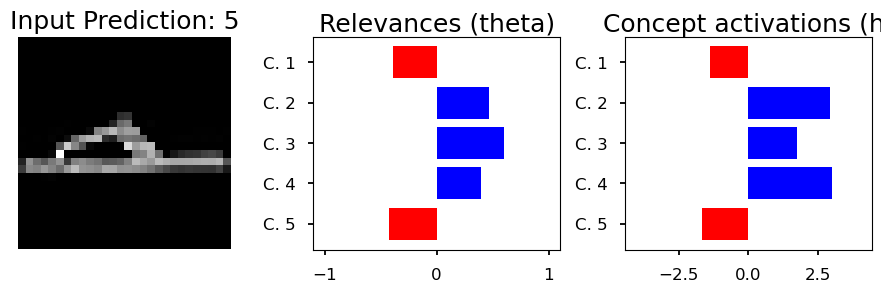

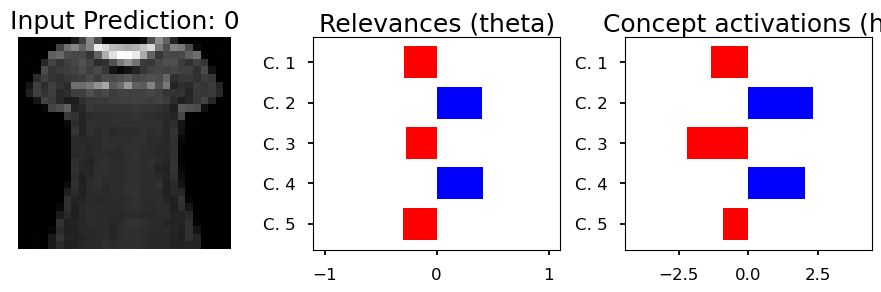

In [13]:
show_explainations(
    model_c5, test_loader_c5,
    dataset='fashion_mnist',
    num_explanations=6,
    batch_size=200
)

### 2.4 SENN Explanations — One Sample per Class

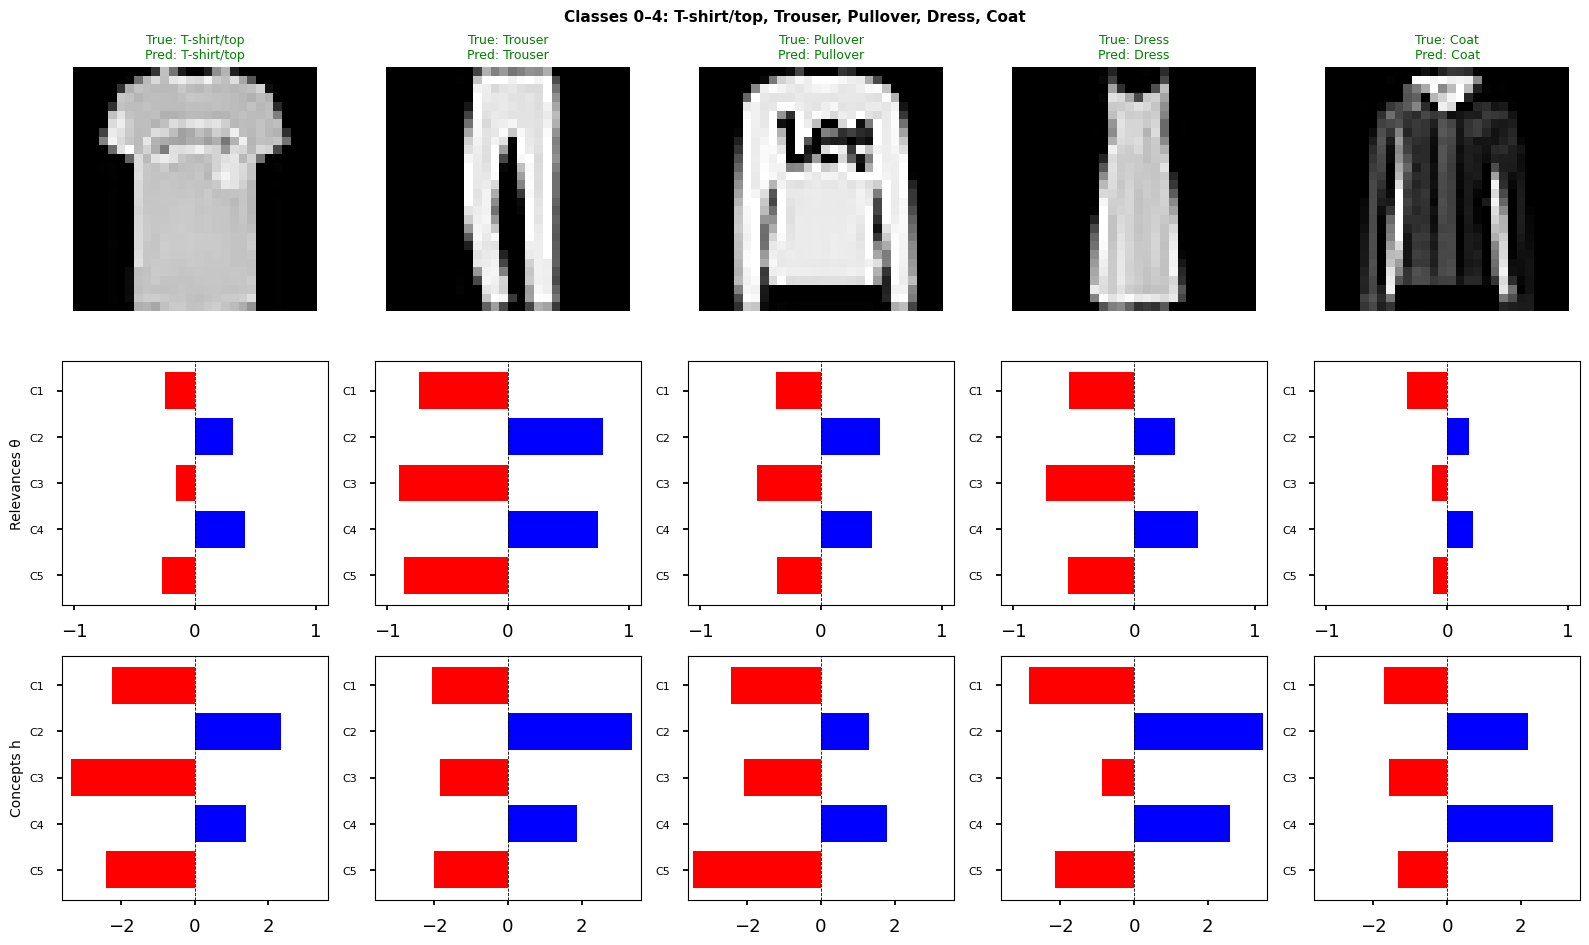

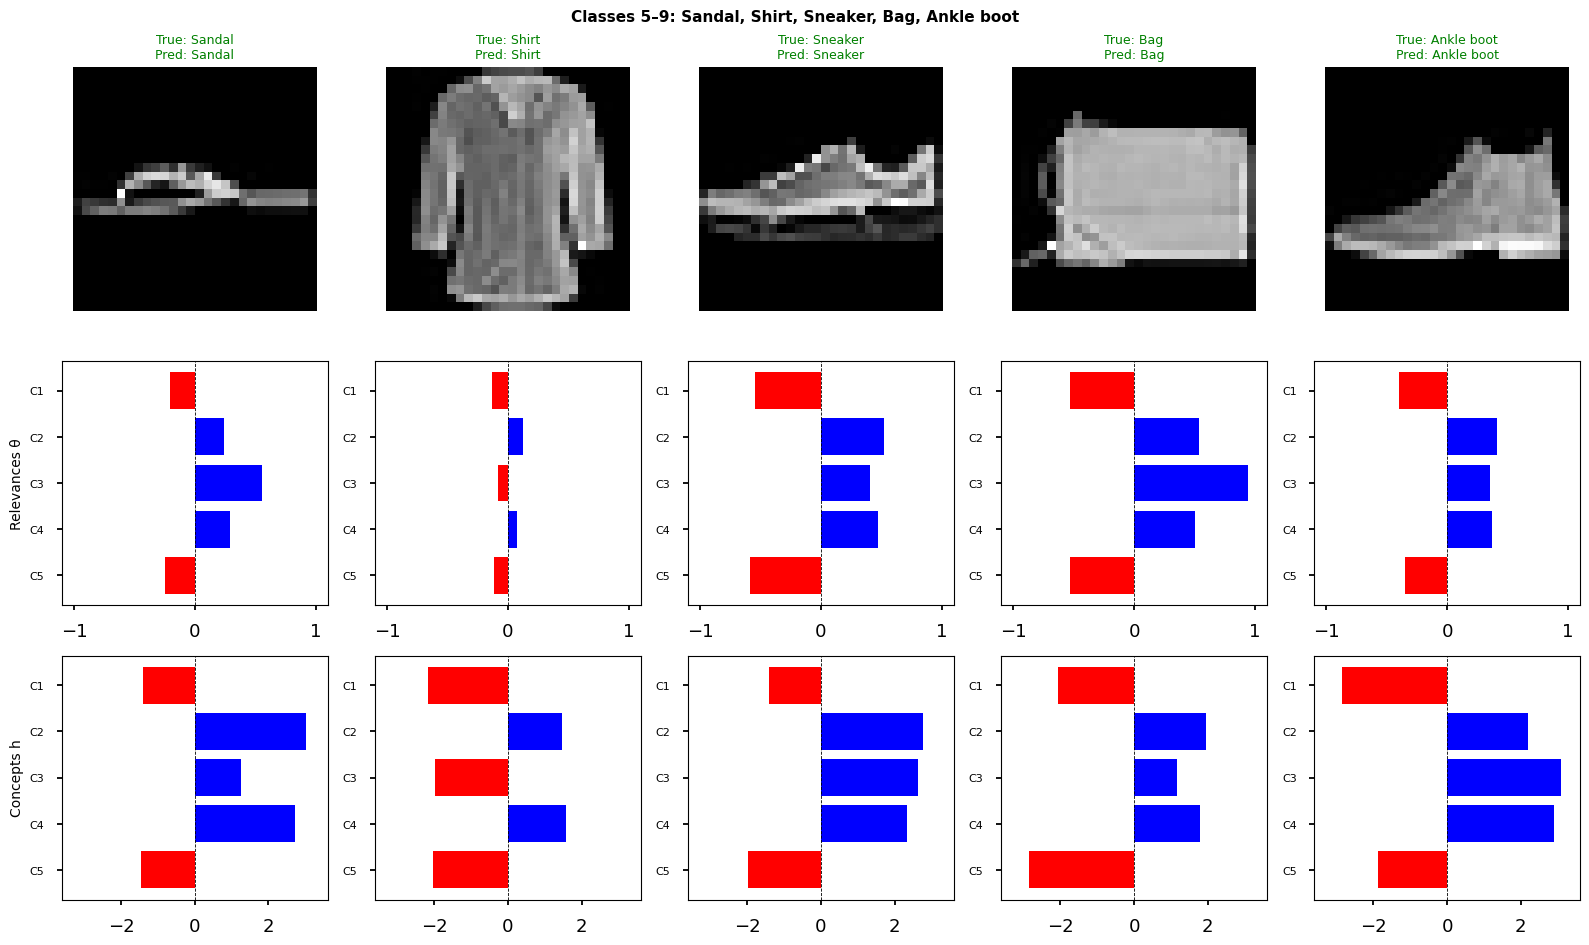

In [14]:
show_per_class_explanations(
    model_c5, test_loader_c5,
    class_names=FASHION_MNIST_CLASSES,
    device='cpu',
    group_size=5
)

### 2.5 Concept Prototypes — Highest Activation

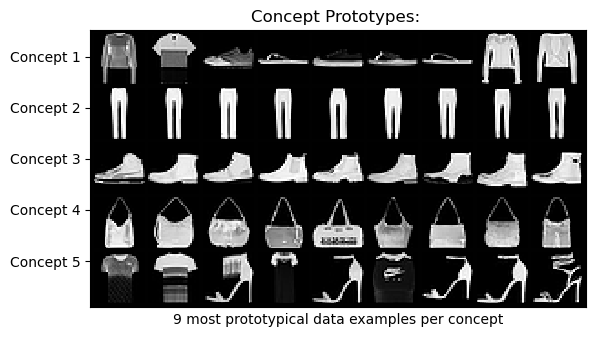

<Figure size 640x480 with 0 Axes>

In [15]:
highest_activations(
    model_c5, test_loader_c5,
    num_concepts=5,
    num_prototypes=9
)

### 2.6 Concept Prototypes — Highest Contrast

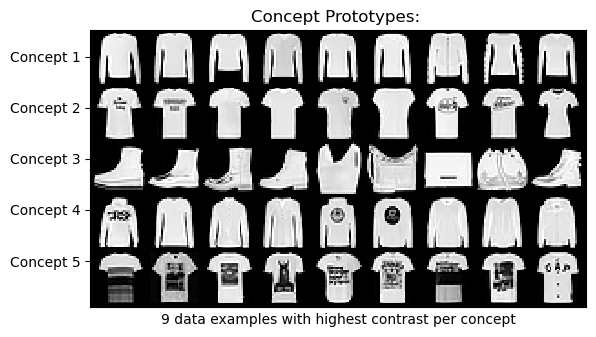

<Figure size 640x480 with 0 Axes>

In [16]:
highest_contrast(
    model_c5, test_loader_c5,
    num_concepts=5,
    num_prototypes=9
)

---
## 3. Comparison: c5 vs c10  (λ = 1e-4)

Side-by-side comparison of the two runs.

In [17]:
# ─── Accuracy table ──────────────────────────────────────────────────────────
results = [
    ('c10  (10 concepts, λ=1e-4)', acc_c10, EXP_C10),
    ('c5   ( 5 concepts, λ=1e-4)', acc_c5,  EXP_C5),
]

header = f"{'Model':<38} {'Test Acc':>12}  {'Best Valid Acc':>15}"
print(header)
print('─' * 68)
for label, test_acc, exp in results:
    valid_acc = pd.read_csv(
        Path('results') / exp / 'accuracies_losses_valid.csv'
    )['Accuracy'].max()
    print(f'{label:<38} {test_acc:>11.4f}  {valid_acc:>14.4f}')
print('─' * 68)

Model                                      Test Acc   Best Valid Acc
────────────────────────────────────────────────────────────────────
c10  (10 concepts, λ=1e-4)                  0.8768          0.8880
c5   ( 5 concepts, λ=1e-4)                  0.8768          0.8880
────────────────────────────────────────────────────────────────────


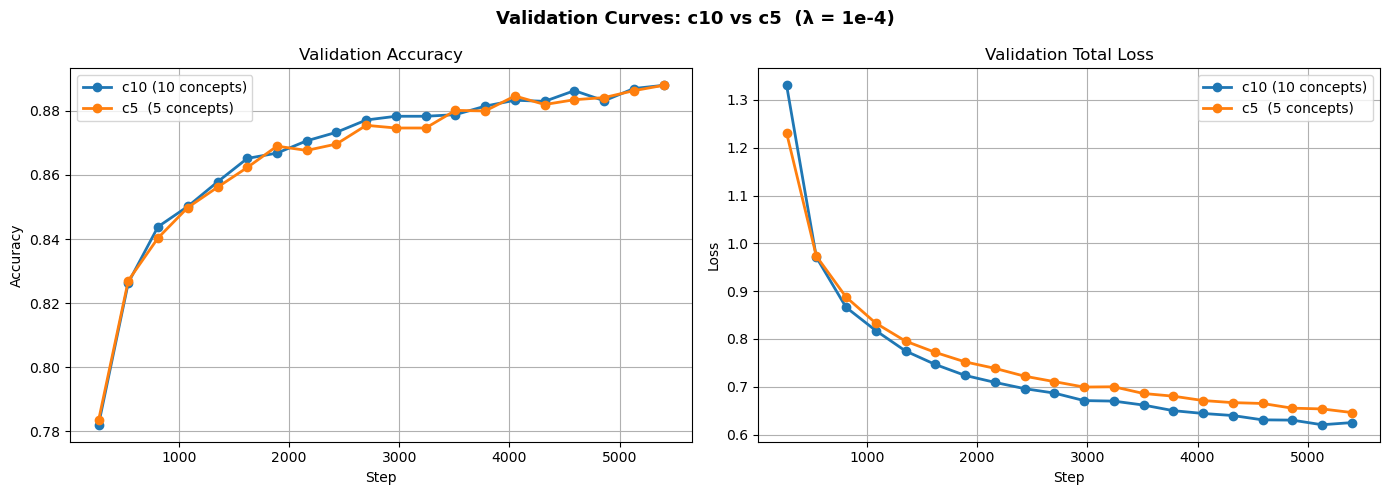

In [18]:
# ─── Validation curves side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validation Curves: c10 vs c5  (λ = 1e-4)', fontsize=13, fontweight='bold')

palette = {'c10 (10 concepts)': 'tab:blue', 'c5  (5 concepts)': 'tab:orange'}
exps    = [(EXP_C10, 'c10 (10 concepts)'), (EXP_C5, 'c5  (5 concepts)')]

for exp_name, label in exps:
    df_v = pd.read_csv(Path('results') / exp_name / 'accuracies_losses_valid.csv')
    color = palette[label]
    axes[0].plot(df_v['Step'], df_v['Accuracy'], label=label, color=color,
                 marker='o', linewidth=2)
    axes[1].plot(df_v['Step'], df_v['Loss'],     label=label, color=color,
                 marker='o', linewidth=2)

for ax, title, ylabel in zip(axes,
                              ['Validation Accuracy', 'Validation Total Loss'],
                              ['Accuracy', 'Loss']):
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

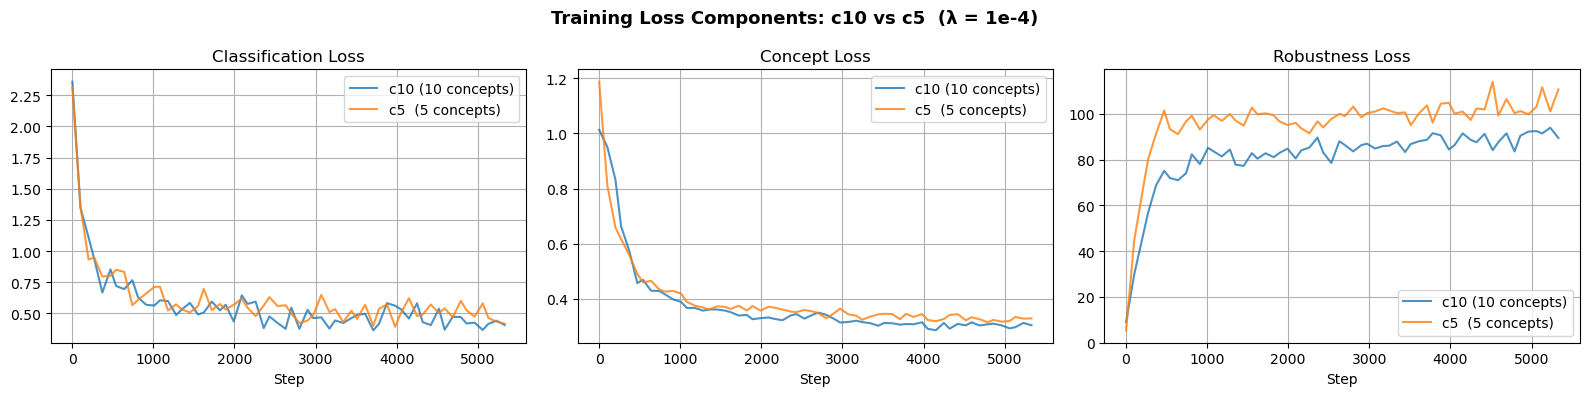

In [19]:
# ─── Training loss component comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Loss Components: c10 vs c5  (λ = 1e-4)', fontsize=13, fontweight='bold')

components = ['Classification_Loss', 'Concept_Loss', 'Robustness_Loss']
titles     = ['Classification Loss', 'Concept Loss', 'Robustness Loss']

for exp_name, label, color in [
    (EXP_C10, 'c10 (10 concepts)', 'tab:blue'),
    (EXP_C5,  'c5  (5 concepts)',  'tab:orange'),
]:
    df_t = pd.read_csv(Path('results') / exp_name / 'accuracies_losses_train.csv')
    for ax, comp, title in zip(axes, components, titles):
        ax.plot(df_t['Step'], df_t[comp], label=label, color=color, alpha=0.8)
        ax.set_title(title)
        ax.set_xlabel('Step')
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

---
## 4. Template: λ Regularization Sweep  *(to be completed)*

When additional runs with different values of the robustness regularization strength λ are available,
fill in the config list below and run the cell.

In [ ]:
# ─── λ comparison — fill in config filenames as more runs become available ───
#
# from senn.utils.plot_utils import plot_lambda_accuracy
#
# config_list = [
#     'fashion_mnist_lambda???_c5_seed29.json',   # λ = ???
#     'fashion_mnist_lambda1e-4_c5_seed29.json',  # λ = 1e-4  (already done)
#     'fashion_mnist_lambda1e-1_seed29.json',     # λ = 1e-1  (already done)
# ]
#
# plot_lambda_accuracy(config_list, valid=True)

print('λ comparison template ready — uncomment and run once more configs are available.')